In [1]:
# Importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading dataset
df = pd.read_csv('data.csv')

# Basic formatting cleanup
df.columns = df.columns.str.strip()
df = df.replace([np.inf, -np.inf], np.nan)

# Standardize driver ID formatting (Class = driver id A..J)
df['Class'] = df['Class'].astype(str).str.strip().str.upper()
df.loc[df['Class'].isin(['', 'NAN', 'NONE', 'NULL']), 'Class'] = np.nan

# Dropping irrelevant features (see report phase 1)
cols_to_drop_phase1 = [
    'Short_Term_Fuel_Trim_Bank1',
    'Engine_soacking_time',
    'Inhibition_of_engine_fuel_cut_off',
    'Fuel_Pressure',
    'Long_Term_Fuel_Trim_Bank1',
    'Current_spark_timing',
    'Engine_coolant_temperature',
    'Engine_Idel_Target_Speed',
    'Minimum_indicated_engine_torque',
    'Maximum_indicated_engine_torque',
    'Torque_scaling_factor(standardization)',
    'Standard_Torque_Ratio',
    'Requested_spark_retard_angle_from_TCU',
    'TCU_requests_engine_torque_limit_(ETL)',
    'TCU_requested_engine_RPM_increase',
    'Target_engine_speed_used_in_lock-up_module',
    'Glow_plug_control_request',
    'Activation_of_Air_compressor',
    'Torque_converter_speed',
    'Engine_coolant_temperature',
    'Torque_converter_turbine_speed_-_Unfiltered',
    'Converter_clutch',
    'Engine_coolant_temperature.1',
]
cols_to_drop_phase1 = list(dict.fromkeys(cols_to_drop_phase1))
df = df.drop(columns=cols_to_drop_phase1, errors='ignore')

# Brief statistical Description of data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Fuel_consumption,94380.0,757.000246,761.376214,0.0,320.0,422.4,1036.80,10931.2
Accelerator_Pedal_value,94380.0,3.718682,8.505756,0.0,0.0,0.0,0.00,99.2
Throttle_position_signal,94380.0,13.208186,16.262249,0.0,6.6,7.5,12.70,100.0
Intake_air_pressure,94380.0,36.853433,27.957584,0.0,4.0,38.0,57.00,178.0
Filtered_Accelerator_Pedal_value,94380.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0
Absolute_throttle_position,94380.0,19.362277,12.079046,12.5,14.5,15.3,19.20,84.3
Engine_in_fuel_cut_off,94380.0,0.067249,0.250455,0.0,0.0,0.0,0.00,1.0
Engine_speed,94380.0,1422.838885,613.428059,0.0,823.0,1473.0,1878.00,6253.0
Engine_torque_after_correction,94380.0,23.813976,14.633545,0.0,14.8,20.3,32.00,83.6
Torque_of_friction,94380.0,13.699580,2.273530,0.0,12.5,13.7,15.20,28.1


In [147]:
# size of dataset after dropping junk features
df.shape

(94380, 32)

In [148]:
# Printing column names
df.columns

Index(['Fuel_consumption', 'Accelerator_Pedal_value',
       'Throttle_position_signal', 'Intake_air_pressure',
       'Filtered_Accelerator_Pedal_value', 'Absolute_throttle_position',
       'Engine_in_fuel_cut_off', 'Engine_speed',
       'Engine_torque_after_correction', 'Torque_of_friction',
       'Flywheel_torque_(after_torque_interventions)', 'Engine_torque',
       'Calculated_LOAD_value', 'Flywheel_torque', 'Current_Gear',
       'Wheel_velocity_front_left-hand', 'Wheel_velocity_rear_right-hand',
       'Wheel_velocity_front_right-hand', 'Wheel_velocity_rear_left-hand',
       'Clutch_operation_acknowledge', 'Gear_Selection', 'Vehicle_speed',
       'Acceleration_speed_-_Longitudinal',
       'Indication_of_brake_switch_ON/OFF', 'Master_cylinder_pressure',
       'Calculated_road_gradient', 'Acceleration_speed_-_Lateral',
       'Steering_wheel_speed', 'Steering_wheel_angle', 'Time(s)', 'Class',
       'PathOrder'],
      dtype='object')

In [149]:
# Checking missing values
missing_by_col = df.isna().sum()
print("Total missing values:", int(missing_by_col.sum()))

Total missing values: 0


In [150]:
# Checking and confirming the data types 
df.dtypes

Fuel_consumption                                float64
Accelerator_Pedal_value                         float64
Throttle_position_signal                        float64
Intake_air_pressure                               int64
Filtered_Accelerator_Pedal_value                  int64
Absolute_throttle_position                      float64
Engine_in_fuel_cut_off                            int64
Engine_speed                                      int64
Engine_torque_after_correction                  float64
Torque_of_friction                              float64
Flywheel_torque_(after_torque_interventions)    float64
Engine_torque                                   float64
Calculated_LOAD_value                           float64
Flywheel_torque                                 float64
Current_Gear                                      int64
Wheel_velocity_front_left-hand                  float64
Wheel_velocity_rear_right-hand                  float64
Wheel_velocity_front_right-hand                 

In [151]:
# checking count of unique values in every column
for col in df.columns:
    print(f"Numbe of unique values in {col}: {df[col].nunique()}")

Numbe of unique values in Fuel_consumption: 542
Numbe of unique values in Accelerator_Pedal_value: 223
Numbe of unique values in Throttle_position_signal: 206
Numbe of unique values in Intake_air_pressure: 158
Numbe of unique values in Filtered_Accelerator_Pedal_value: 1
Numbe of unique values in Absolute_throttle_position: 184
Numbe of unique values in Engine_in_fuel_cut_off: 2
Numbe of unique values in Engine_speed: 2965
Numbe of unique values in Engine_torque_after_correction: 215
Numbe of unique values in Torque_of_friction: 58
Numbe of unique values in Flywheel_torque_(after_torque_interventions): 1895
Numbe of unique values in Engine_torque: 215
Numbe of unique values in Calculated_LOAD_value: 225
Numbe of unique values in Flywheel_torque: 1895
Numbe of unique values in Current_Gear: 8
Numbe of unique values in Wheel_velocity_front_left-hand: 937
Numbe of unique values in Wheel_velocity_rear_right-hand: 1131
Numbe of unique values in Wheel_velocity_front_right-hand: 1128
Numbe of

In [152]:
print(df['Accelerator_Pedal_value'].describe())
print(df['Filtered_Accelerator_Pedal_value'].describe())
# Drop Filtered Accelerator value (constant column) (no variation)
df = df.drop(columns=['Filtered_Accelerator_Pedal_value'])

count    94380.000000
mean         3.718682
std          8.505756
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         99.200000
Name: Accelerator_Pedal_value, dtype: float64
count    94380.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Filtered_Accelerator_Pedal_value, dtype: float64


In [153]:
df['Class'].value_counts()

Class
D    13244
B    12864
F    11012
H     9880
J     8904
E     8436
I     7808
C     7500
G     7492
A     7240
Name: count, dtype: int64

In [154]:
# Checking for duplicates
full_dup_count = df.duplicated().sum()
print(f"Full-row duplicates: {full_dup_count}")
# No duplicates

Full-row duplicates: 0


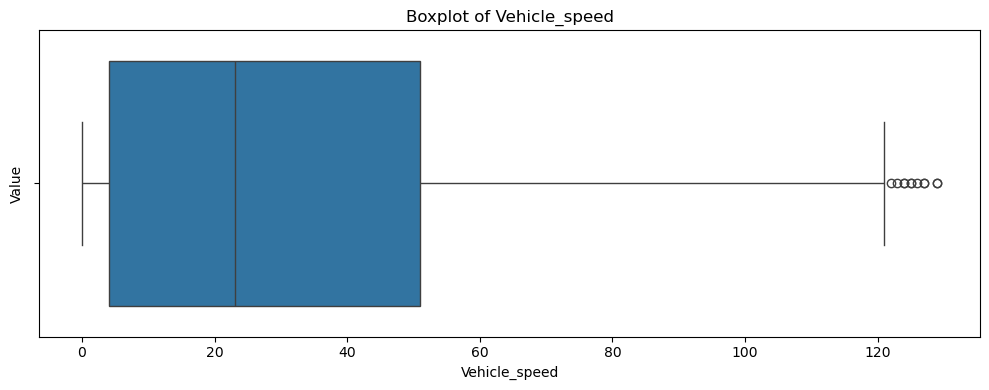

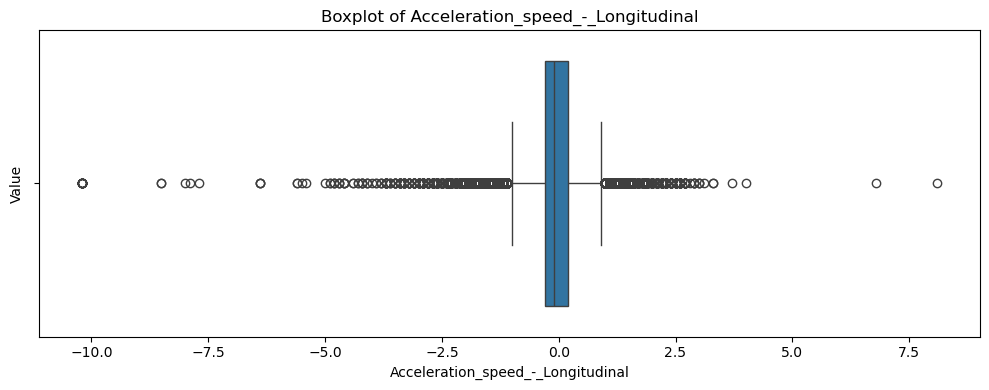

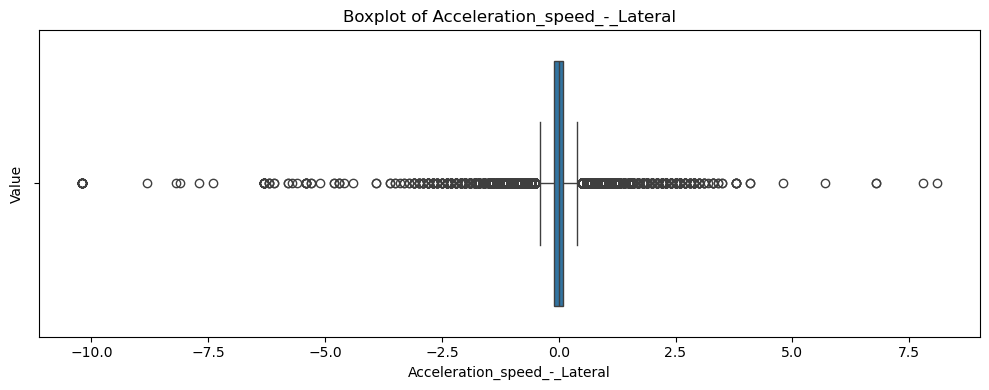

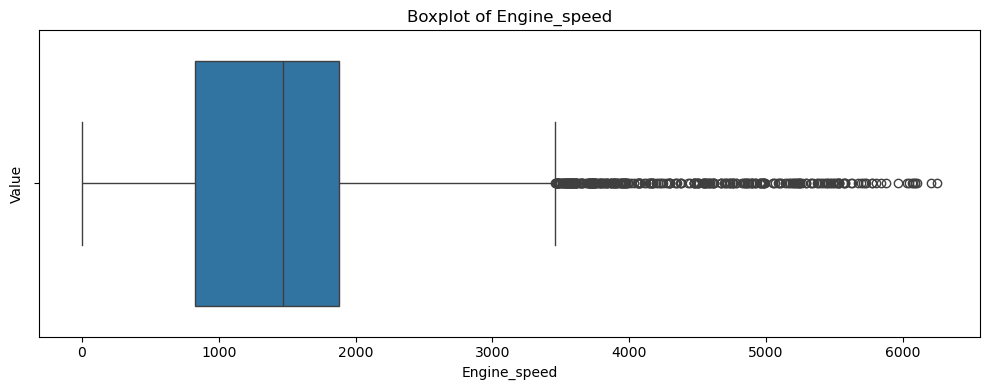

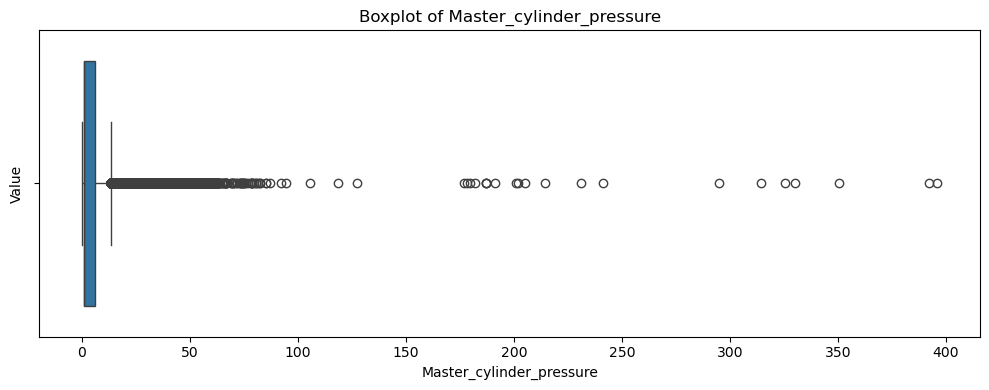

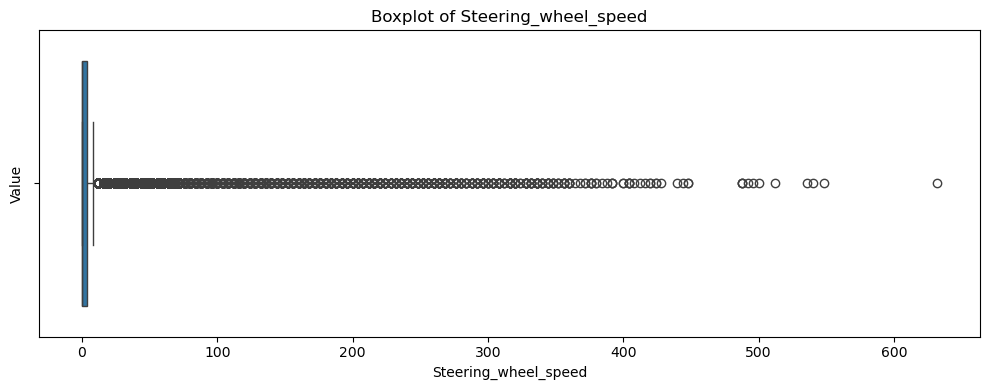

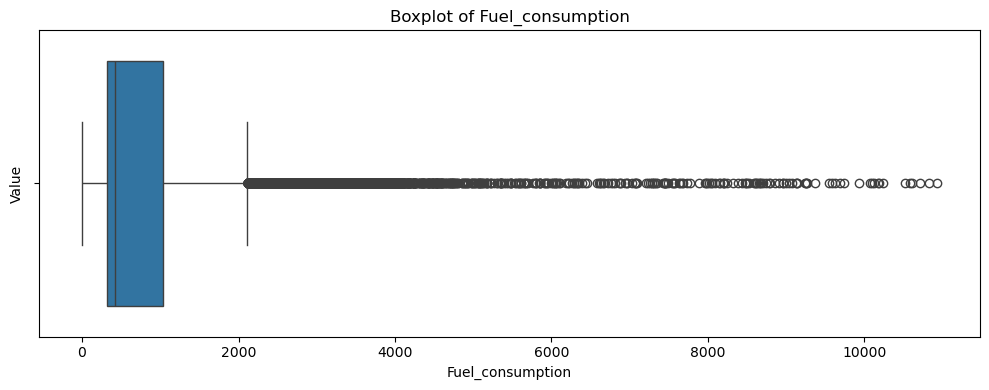

In [155]:
key_features = ['Vehicle_speed',
                'Acceleration_speed_-_Longitudinal',
                'Acceleration_speed_-_Lateral',
                'Engine_speed',
                'Master_cylinder_pressure',
                'Steering_wheel_speed',
                'Fuel_consumption',
                ]
for col in key_features:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x=col)
    plt.xlabel(col)
    plt.ylabel("Value")
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [156]:
def count_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3=  df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
outlier_summary = []

for col in numeric_cols:
    outlier_count = count_outliers(df, col)
    outlier_percentage = (outlier_count / len(df)) * 100
    outlier_summary.append(
        {
            "Feature": col,
            "Outlier_Count": outlier_count,
            "Outlier_Percentage": outlier_percentage
        }
    )

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values("Outlier_Percentage", ascending=False)
print(outlier_df)

                                         Feature  Outlier_Count  \
24                      Calculated_road_gradient          28728   
1                        Accelerator_Pedal_value          23529   
27                          Steering_wheel_angle          15637   
23                      Master_cylinder_pressure          13757   
25                  Acceleration_speed_-_Lateral          12336   
26                          Steering_wheel_speed           9579   
21             Acceleration_speed_-_Longitudinal           8545   
2                       Throttle_position_signal           7556   
4                     Absolute_throttle_position           7393   
5                         Engine_in_fuel_cut_off           6347   
0                               Fuel_consumption           5363   
19                                Gear_Selection           5171   
11                         Calculated_LOAD_value           3728   
8                             Torque_of_friction           247

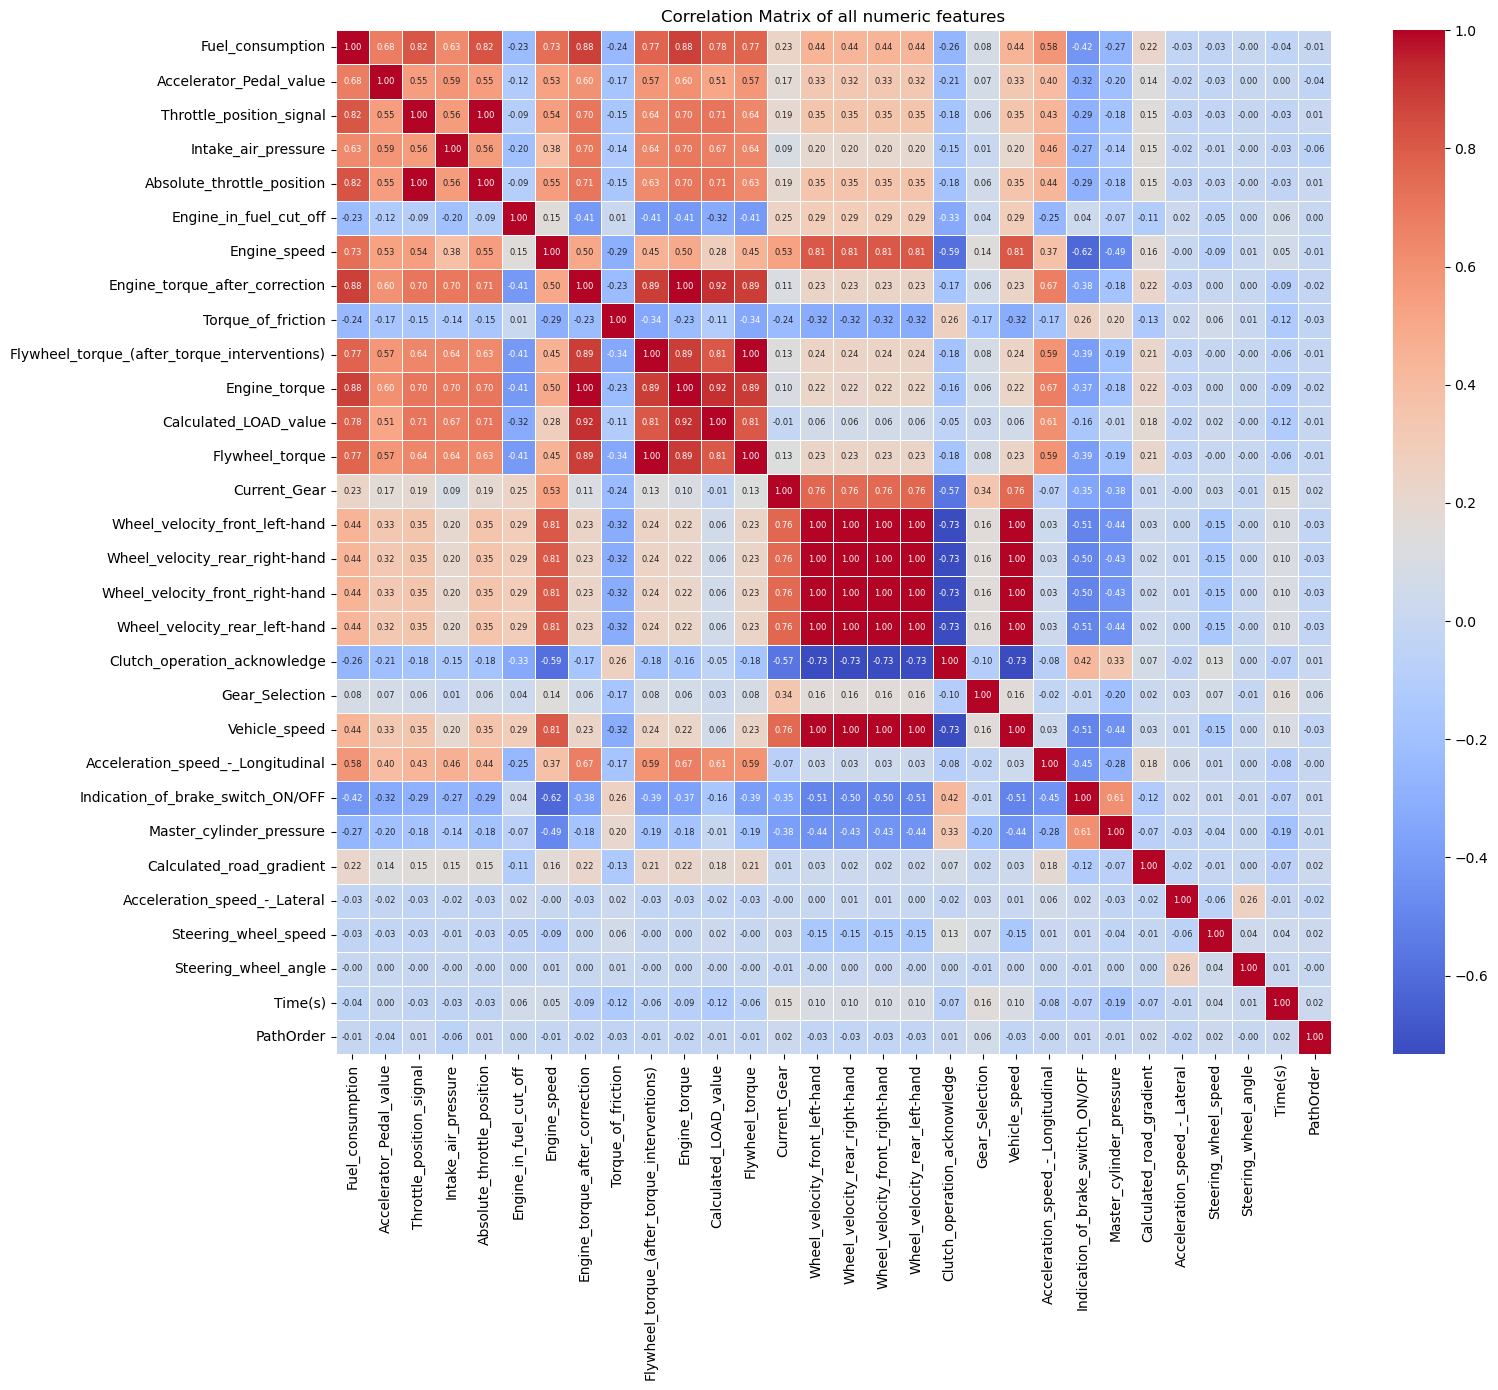

In [157]:
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16,14))
sns.heatmap(correlation_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={'size': 6}
            )
plt.title('Correlation Matrix of all numeric features')
plt.tight_layout()
plt.show()

In [158]:
# finding highly correlated pairs
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i,j]) > 0.9:
            high_corr.append(
                {
                    'Feature 1': correlation_matrix.columns[i],
                    'Feature 2': correlation_matrix.columns[j],
                    'Corr': round(correlation_matrix.iloc[i,j], 3),
                }
            )
high_corr_df = pd.DataFrame(high_corr)
print("Highly Correlated Features (>0.9 or <-0.9):")
print(high_corr_df)

Highly Correlated Features (>0.9 or <-0.9):
                                       Feature 1  \
0                       Throttle_position_signal   
1                 Engine_torque_after_correction   
2                 Engine_torque_after_correction   
3   Flywheel_torque_(after_torque_interventions)   
4                                  Engine_torque   
5                 Wheel_velocity_front_left-hand   
6                 Wheel_velocity_front_left-hand   
7                 Wheel_velocity_front_left-hand   
8                 Wheel_velocity_front_left-hand   
9                 Wheel_velocity_rear_right-hand   
10                Wheel_velocity_rear_right-hand   
11                Wheel_velocity_rear_right-hand   
12               Wheel_velocity_front_right-hand   
13               Wheel_velocity_front_right-hand   
14                 Wheel_velocity_rear_left-hand   

                          Feature 2   Corr  
0        Absolute_throttle_position  0.996  
1                     Engine_torq

In [159]:
# Maybe consider dropping highly correlated features (for linear models, but not for now)
''' cols_to_drop = [
    'Absolute_throttle_position',
    'Engine_torque',
    'Flywheel_torque',
    'Wheel_velocity_front_left-hand',
    'Wheel_velocity_rear_right-hand',
    'Wheel_velocity_front_right-hand',
    'Wheel_velocity_rear_left-hand'
]
df = df.drop(columns=cols_to_drop)
df.shape
'''
df.shape

(94380, 31)

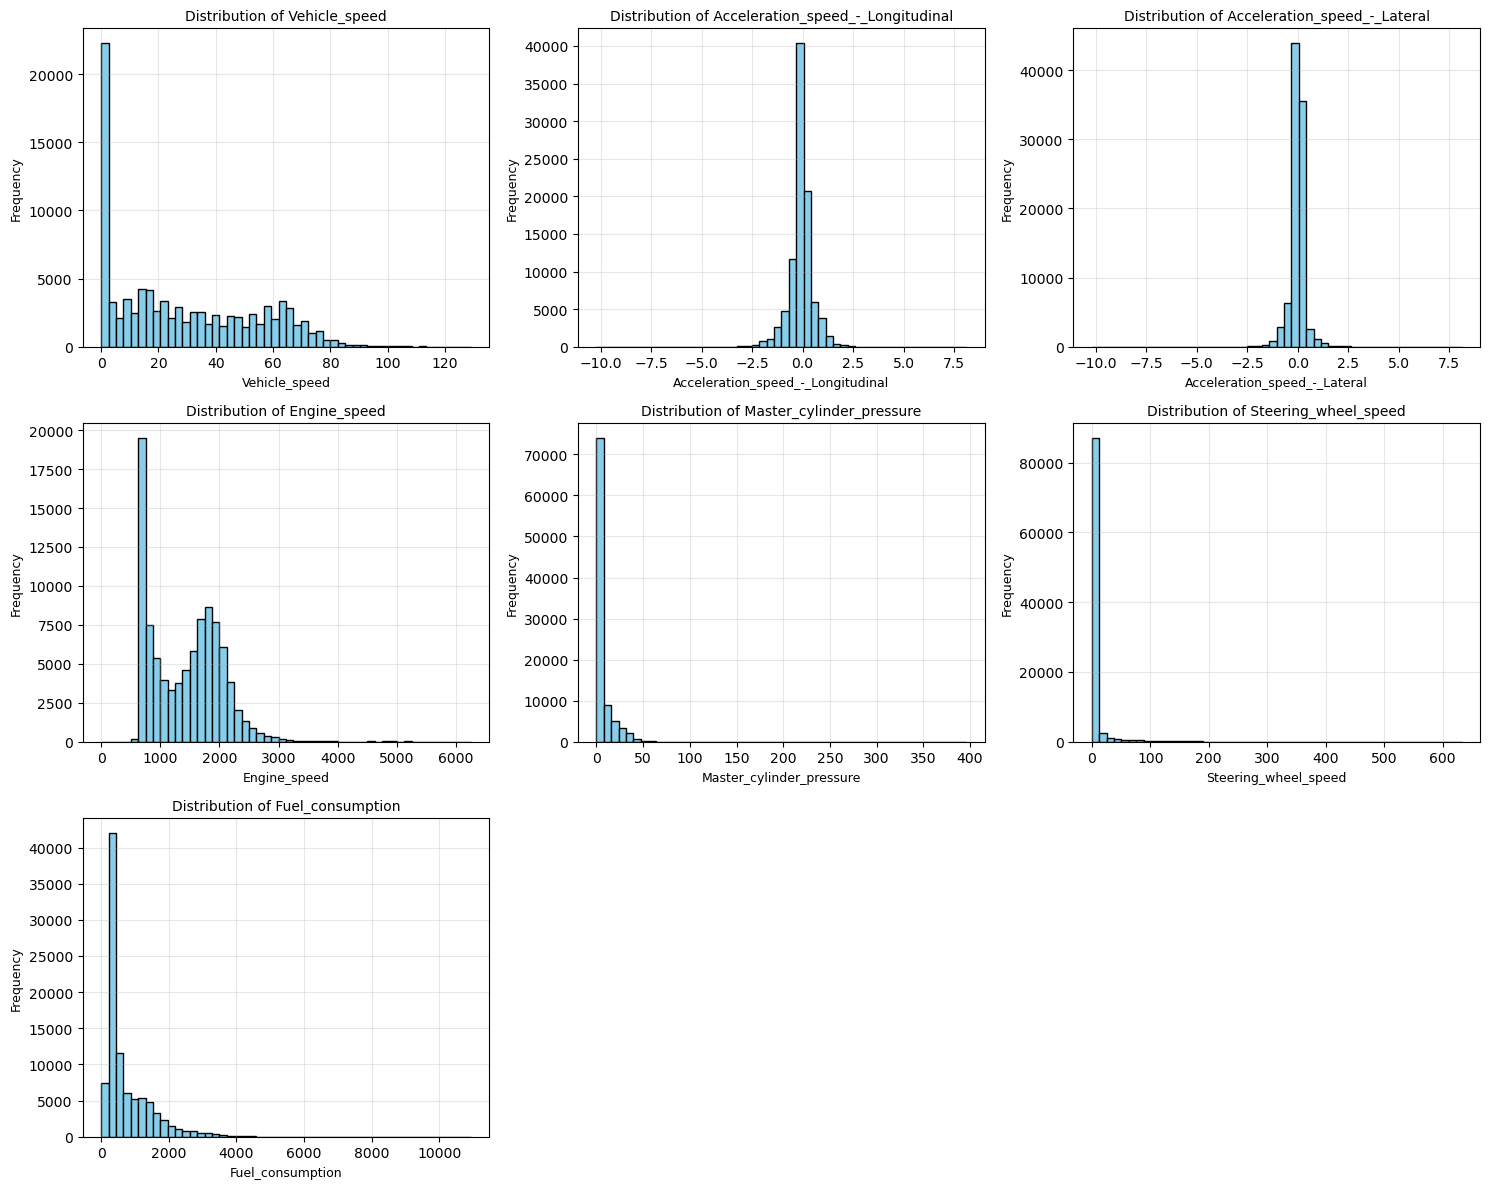

In [160]:
fig, axes = plt.subplots(3,3, figsize=(15,12))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].hist(df[col], bins=50, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].grid(alpha=0.3)

# Hide extra empty subplots
for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [161]:
# Export a unified cleaned dataset (standardized column names)
import re

def to_snake_case(name: str) -> str:
    name = str(name).strip()
    name = re.sub(r"[^0-9a-zA-Z]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_").lower()

clean_df = df.copy()
clean_df.columns = [to_snake_case(c) for c in clean_df.columns]

# Rename Class to driver_id
if 'class' in clean_df.columns:
    clean_df = clean_df.rename(columns={'class': 'driver_id'})

# Saving the cleaned dataset
clean_df.to_csv('cleaned_data.csv', index=False)
print("Saved: cleaned_data.csv")
print("Final shape:", clean_df.shape)

Saved: cleaned_data.csv
Final shape: (94380, 31)
